## Team Members and Contributions

- Member 1: Data Cleaning and Preprocessing  
- Member 2: Exploratory Data Analysis and Visualizations  
- Member 3: Machine Learning Model Development and Evaluation  
- Member 4: Reporting and Final Conclusions  

## Project Overview

Cardiovascular disease is one of the leading causes of death worldwide. The aim of this project is to analyze patient health records, identify patterns associated with heart disease, and develop a machine learning model capable of predicting the presence of heart disease. The findings from this analysis can help support early detection and improve clinical decision-making.

In [1]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

In [2]:
import pandas as pd

df = pd.read_csv("heart_disease_uci.zip", compression="zip")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Initial Data Exploration

This section examines the structure of the dataset, including the number of observations, variables, and data types before any cleaning is performed.

In [3]:
# ============================================
# Explore Dataset
# ============================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(920, 16)

Column Names:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int

## Dataset Overview

The dataset contains 920 patient records and 16 variables related to cardiovascular health. These include demographic information (age, sex), clinical measurements (cholesterol, blood pressure), and diagnostic test results. The target variable is used to indicate the presence or absence of heart disease.

## Data Cleaning Audit

This section handles missing values, checks data types, and prepares the dataset for analysis and machine learning.

In [4]:
# Check missing values in each column
df.isnull().sum().sort_values(ascending=False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
cp            0
dataset       0
id            0
age           0
sex           0
num           0
dtype: int64

In [5]:
# Fill numeric missing values with median
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [6]:
# Convert target variable (num) into binary classification
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

In [7]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps      0
chol          0
fbs          90
restecg       2
thalch        0
exang        55
oldpeak       0
slope       309
ca            0
thal        486
num           0
dtype: int64

## Handling Missing Values

Missing values were handled carefully based on the proportion of missing data in each column. Columns with a high proportion of missing values were dropped, while numerical columns with small missing values were imputed using the median.

In [8]:
# Drop columns with excessive missing values
df = df.drop(columns=['ca', 'thal'])

In [9]:
# Safer way to handle missing values

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype != 'object':
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

/tmp/ipykernel_1607/3098276696.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [10]:
df.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64

## Exploratory Data Analysis

In this section, we explore patterns in the dataset using summary statistics and grouped analysis by age and gender.

In [11]:
# Create age groups for analysis
bins = [20, 30, 40, 50, 60, 70, 80, 90]

labels = ["20-29","30-39","40-49","50-59","60-69","70-79","80-89"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

In [12]:
df.groupby("age_group", observed=True).mean(numeric_only=True)

,id,age,trestbps,chol,fbs,thalch,exang,oldpeak,num
age_group,,,,,,,,,
20-29,271.000000,29.000000,138.000000,207.800000,0.000000,177.400000,0.000000,0.000000,0.000000
30-39,387.806818,36.897727,123.931818,206.727273,0.022727,154.909091,0.204545,0.462500,0.363636
40-49,386.187500,45.674107,128.035714,216.441964,0.062500,144.852679,0.299107,0.606696,0.415179
50-59,471.486911,55.465969,133.329843,198.486911,0.183246,134.963351,0.405759,0.913613,0.583770
60-69,536.969543,64.233503,136.685279,180.969543,0.228426,127.796954,0.446701,1.181218,0.736041
70-79,657.541667,73.541667,137.541667,197.041667,0.291667,124.125000,0.375000,1.112500,0.666667


In [13]:
# Mean values grouped by gender
df.groupby("sex").mean(numeric_only=True)

,id,age,trestbps,chol,fbs,thalch,exang,oldpeak,num
sex,,,,,,,,,
Female,316.618557,52.474227,132.072165,240.814433,0.097938,146.180412,0.221649,0.667526,0.257732
Male,498.947658,53.787879,131.975207,188.977961,0.163912,135.424242,0.404959,0.902893,0.632231


## Data Visualization

This section presents key visual insights from the dataset, including distributions, relationships, and patterns related to heart disease.

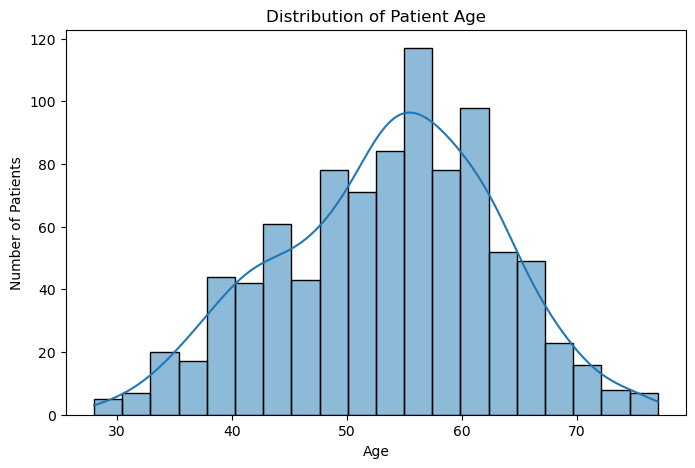

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=20, kde=True)

plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

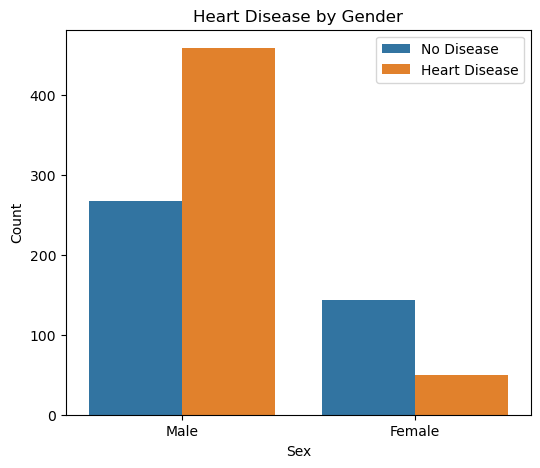

In [15]:
plt.figure(figsize=(6,5))

sns.countplot(x="sex", hue="num", data=df)

plt.title("Heart Disease by Gender")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.legend(["No Disease", "Heart Disease"])

plt.show()

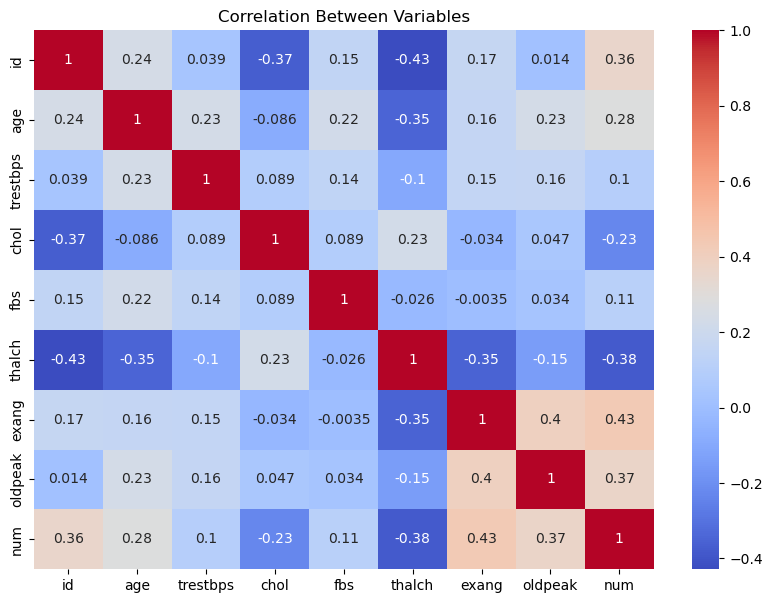

In [16]:
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Between Variables")

plt.show()

### Key Observations from Visualizations

- Age distribution shows most patients are middle-aged to elderly.
- Heart disease is more prevalent in certain gender groups.
- Some clinical variables show stronger correlation with heart disease than others.

## Machine Learning Model

In this section, we train a classification model to predict the presence of heart disease using patient health data.

In [17]:
# Separate features and target variable

X = df.drop("num", axis=1)
y = df["num"]

In [18]:
# Convert categorical variables into dummy variables

X = pd.get_dummies(X, drop_first=True)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
y_pred = model.predict(X_test_scaled)

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.8152173913043478
Precision: 0.8571428571428571
Recall: 0.8256880733944955


## Final Conclusion

The logistic regression model achieved good performance in predicting heart disease.

- Accuracy: 81.5%
- Precision: 85.7%
- Recall: 82.6%

These results indicate that the model is effective at identifying patients with heart disease while maintaining a good balance between precision and recall.

### Key Insights
- The dataset contains strong patterns that can be used for prediction.
- Age and clinical test results are important indicators of heart disease risk.
- The model performs reasonably well and could support early screening efforts.

### Recommendations
- Patients with abnormal clinical readings should be prioritized for further medical testing.
- Regular screening should be encouraged for older age groups.
- Future improvements could include trying more advanced models like Random Forest or XGBoost for higher accuracy.